In [1]:
import importlib, sys
sys.path.insert(0, 'code')
import variants
importlib.reload(variants)
print('three_channel_pinn' in dir(variants))

True


In [2]:
import os, sys, time
import numpy as np
import torch
import matplotlib.pyplot as plt
sys.path.insert(0, 'code')
from shared import load_condition, glauber_constants, mse, DATA_FILE, DATA_DIR
from variants import (
    three_separate_pinns,
    inverse_pinn,
    pinn_analytical,
    three_channel_pinn,
    per_run_pinn,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

plt.rcParams.update({
    "axes.titlesize":  14,
    "axes.labelsize":  13,
    "legend.fontsize": 11,
})

device: cpu


In [3]:
DATA_DIR_2 = 'data_grid_2'
data_path  = os.path.join(DATA_DIR_2, DATA_FILE)
data = load_condition(data_path=data_path, return_per_run=True)

t_grid = data['t_grid']
m_bar = data['m_bar']
eps_bar = data['eps_bar']
eps2_bar = data['eps2_bar']
a0_true, a1_true, a2_true = glauber_constants(
    data['beta_true'], data['h_true'], data['J_true']
)

print(f'Source : {data_path}')
print(f'Condition : β={data["beta_true"]:+.3f}  h={data["h_true"]:+.3f}  J={data["J_true"]:+.3f}')
print(f'Analytical : (a₀, a₁, a₂) = ({a0_true:+.4f}, {a1_true:+.4f}, {a2_true:+.4f})')

Source : data_grid_2/cond_046.npz
Condition : β=+0.900  h=-1.000  J=+0.500
Analytical : (a₀, a₁, a₂) = (-1.1897, +0.4734, +0.2429)


In [4]:
results = {}

for fn, key in [
    (three_separate_pinns, 'three_separate'),
    (inverse_pinn, 'inverse'),
    (pinn_analytical, 'analytical'),
    (three_channel_pinn, 'three_channel'),
    (per_run_pinn, 'per_run'),
]:
    print(f'\n {fn.__name__}')
    r = fn(data, device=device)
    r['mse_m'] = mse(r['m_hat'],    m_bar)
    r['mse_eps'] = mse(r['eps_hat'],  eps_bar)
    r['mse_eps2'] = mse(r['eps2_hat'], eps2_bar)
    r['da0'] = abs(r['a0'] - a0_true)
    r['da1'] = abs(r['a1'] - a1_true)
    r['da2'] = abs(r['a2'] - a2_true)
    r['da_mean'] = (r['da0'] + r['da1'] + r['da2']) / 3.0
    results[key] = r
    print(f'MSE m = {r["mse_m"]:.2e} MSE ε = {r["mse_eps"]:.2e}  MSE ε₂ = {r["mse_eps2"]:.2e}')
    print(f'recovered (a₀, a₁, a₂) = ({r["a0"]:+.4f}, {r["a1"]:+.4f}, {r["a2"]:+.4f})')
    print(f'mean Δa = {r["da_mean"]:.3e} {r["n_params"]:,} params {r["time_sec"]:.1f} s')


 three_separate_pinns


/Users/mekhachatryan/DS Capstone/code/shared.py:93: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  history.append(float(L))


MSE m = 1.39e-04 MSE ε = 1.32e-04  MSE ε₂ = 8.76e-05
recovered (a₀, a₁, a₂) = (-0.8479, +0.0832, -0.9919)
mean Δa = 6.556e-01 38,028 params 29.3 s

 inverse_pinn
MSE m = 1.79e-06 MSE ε = 3.81e-06  MSE ε₂ = 1.12e-03
recovered (a₀, a₁, a₂) = (-1.0785, +0.5529, +0.2857)
mean Δa = 7.785e-02 12,676 params 13.2 s

 pinn_analytical
MSE m = 3.11e-06 MSE ε = 3.69e-06  MSE ε₂ = 5.22e-03
recovered (a₀, a₁, a₂) = (-0.7319, +0.1623, -0.9512)
mean Δa = 6.543e-01 12,676 params 12.0 s

 three_channel_pinn
MSE m = 4.19e-05 MSE ε = 7.27e-05  MSE ε₂ = 6.31e-05
recovered (a₀, a₁, a₂) = (-1.3769, +0.3664, +0.2491)
mean Δa = 1.001e-01 12,806 params 18.1 s

 per_run_pinn
MSE m = 5.55e-06 MSE ε = 8.63e-06  MSE ε₂ = 4.83e-03
recovered (a₀, a₁, a₂) = (-0.7861, +0.1592, -0.8966)
mean Δa = 6.191e-01 12,676 params 12.2 s


In [5]:
header = (f'{"variant":<42s}  {"MSE m":>9s}  {"MSE ε":>9s}  {"MSE ε₂":>9s}  '
          f'{"Δa mean":>11s}  {"params":>8s}  {"time (s)":>8s}')
for key in ['three_separate', 'inverse', 'analytical', 'three_channel', 'per_run']:
    r = results[key]
    print(f'{r["name"]:<42s}  '
          f'{r["mse_m"]:>9.2e}  {r["mse_eps"]:>9.2e}  {r["mse_eps2"]:>9.2e}  '
          f'{r["da_mean"]:>11.3e}  {r["n_params"]:>8,d}  {r["time_sec"]:>8.1f}')

Three separate PINNs                         1.39e-04   1.32e-04   8.76e-05    6.556e-01    38,028      29.3
Inverse PINN  (β, h, J learnable)            1.79e-06   3.81e-06   1.12e-03    7.785e-02    12,676      13.2
PINN-Analytical (chosen)                     3.11e-06   3.69e-06   5.22e-03    6.543e-01    12,676      12.0
3-channel PINN (fully supervised)            4.19e-05   7.27e-05   6.31e-05    1.001e-01    12,806      18.1
Per-run PINN  (single sub-run, R[idx]=0)     5.55e-06   8.63e-06   4.83e-03    6.191e-01    12,676      12.2


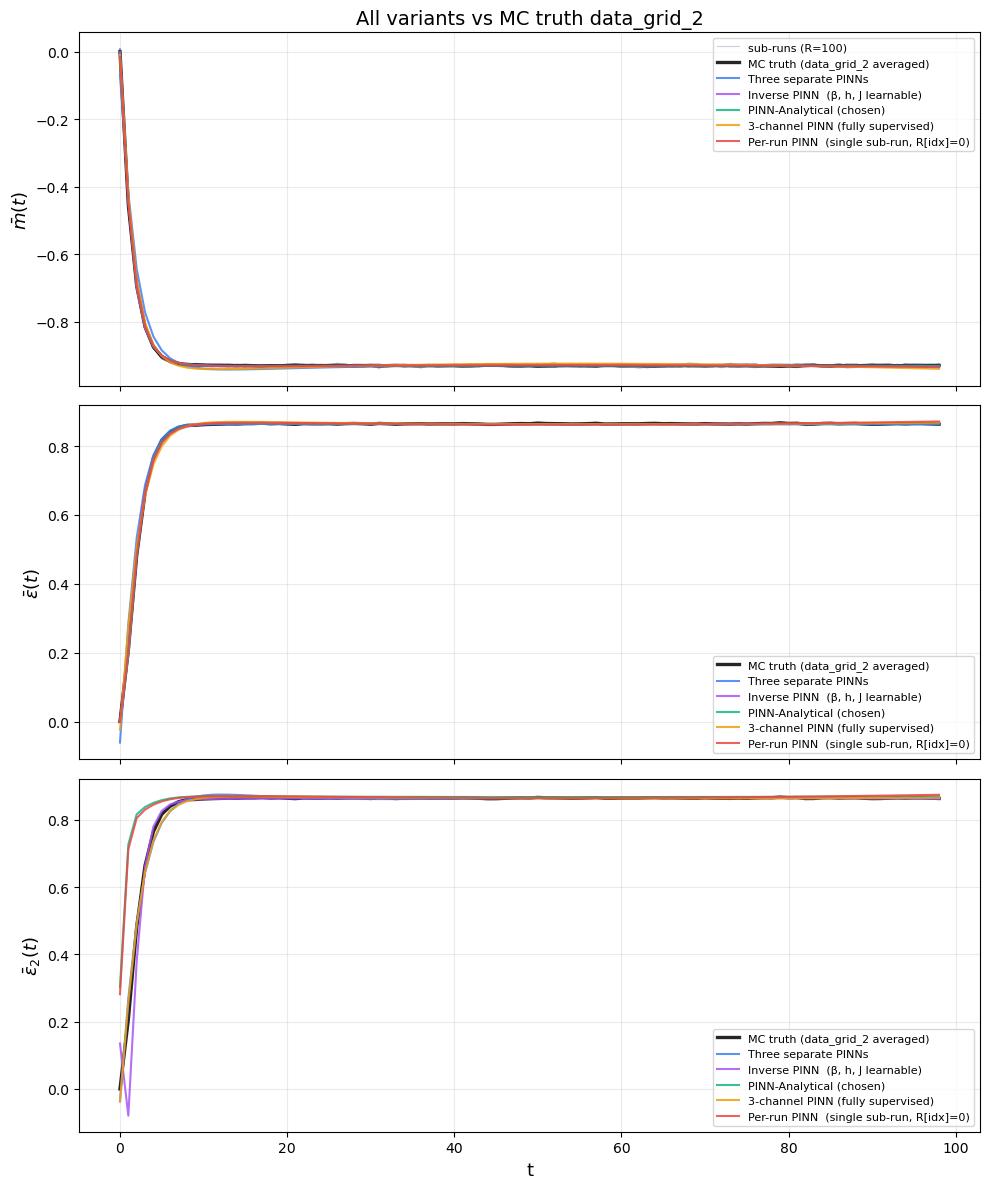

In [6]:
colors = {'three_separate': '#3b82f6', 'inverse': '#a855f7', 'analytical': '#10b981',
          'three_channel':       '#f59e0b', 'per_run': '#ef4444'}

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
for ax_idx, (ax, (truth, key_obs, lbl)) in enumerate(zip(axes, [
    (m_bar,    'm_hat',    r'$\bar m(t)$'),
    (eps_bar,  'eps_hat',  r'$\bar\varepsilon(t)$'),
    (eps2_bar, 'eps2_hat', r'$\bar\varepsilon_2(t)$'),
])):
    if ax_idx == 0 and 'm_per_run' in data:
        for run in data['m_per_run']:
            ax.plot(t_grid, run, color='#94a3b8', lw=0.8, alpha=0.25, zorder=0)
        ax.plot([], [], color='#94a3b8', lw=0.8, alpha=0.5,
                label=f'sub-runs (R={data["m_per_run"].shape[0]})')
    ax.plot(t_grid, truth, 'k-', lw=2.4, alpha=0.85, label='MC truth (data_grid_2 averaged)')
    for key, r in results.items():
        ax.plot(t_grid, r[key_obs], color=colors[key], lw=1.5, alpha=0.85, label=r['name'])
    ax.set_ylabel(lbl); ax.grid(alpha=0.25); ax.legend(fontsize=8, loc='best')
axes[-1].set_xlabel('t')
axes[0].set_title('All variants vs MC truth data_grid_2')
plt.tight_layout(); plt.show()

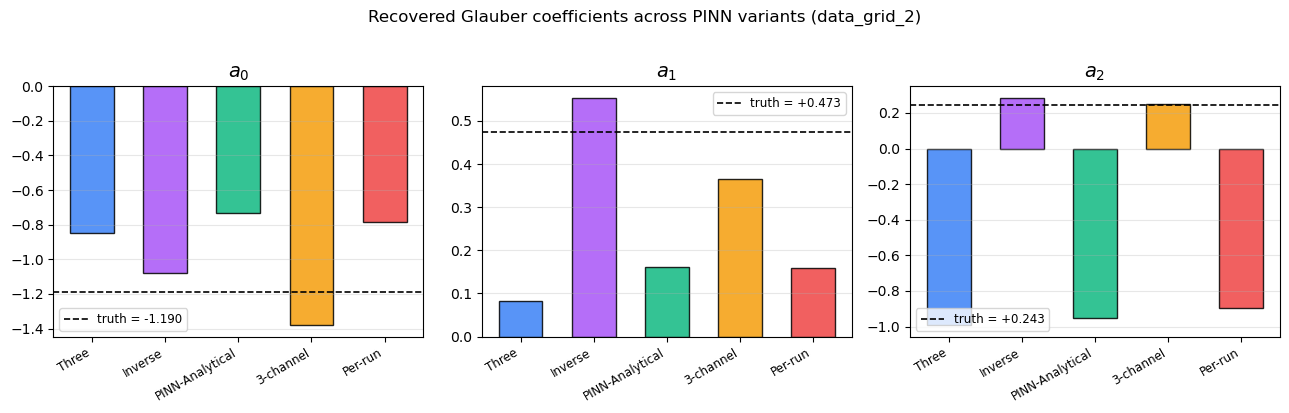

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (lbl, key_a, true_val) in zip(axes, [
    (r'$a_0$', 'a0', a0_true),
    (r'$a_1$', 'a1', a1_true),
    (r'$a_2$', 'a2', a2_true),
]):
    names  = [results[k]['name'].split(' ')[0] for k in results]
    values = [results[k][key_a]                for k in results]
    bar_colors = [colors[k]                    for k in results]
    xs = np.arange(len(values))
    ax.bar(xs, values, 0.6, color=bar_colors, edgecolor='black', alpha=0.85)
    ax.axhline(true_val, color='k', ls='--', lw=1.2, label=f'truth = {true_val:+.3f}')
    ax.set_xticks(xs); ax.set_xticklabels(names, rotation=30, ha='right', fontsize=8.5)
    ax.set_title(lbl); ax.grid(True, axis='y', alpha=0.3)
    ax.legend(fontsize=8.5, loc='best')
plt.suptitle('Recovered Glauber coefficients across PINN variants (data_grid_2)', y=1.02)
plt.tight_layout(); plt.show()

In [8]:
data_grid_1 = load_condition(
    data_path=os.path.join(DATA_DIR, DATA_FILE), return_per_run=True
)
r1 = pinn_analytical(data_grid_1, device=device)
r2 = results['analytical']

for label, r, truth_m, truth_e, truth_e2 in [
    ('data_grid', r1, data_grid_1['m_bar'], data_grid_1['eps_bar'], data_grid_1['eps2_bar']),
    ('data_grid_2', r2, m_bar, eps_bar, eps2_bar),
]:
    print(f'\nPINN-Analytical on {label}')
    print(f'MSE m = {mse(r["m_hat"], truth_m):.2e}')
    print(f'MSE ε = {mse(r["eps_hat"], truth_e):.2e}')
    print(f'MSE ε₂ = {mse(r["eps2_hat"], truth_e2):.2e}')
    print(f'recovered (a₀, a₁, a₂) = ({r["a0"]:+.4f}, {r["a1"]:+.4f}, {r["a2"]:+.4f})')

print('\nCross-dataset agreement on recovered scalars:')
for nm in ['a0', 'a1', 'a2']:
    d = abs(r1[nm] - r2[nm])
    print(f'  {nm} (grid1) − {nm} = {d:.3e}')


PINN-Analytical on data_grid
MSE m = 2.56e-06
MSE ε = 2.67e-05
MSE ε₂ = 8.90e-05
recovered (a₀, a₁, a₂) = (+0.0841, +0.7183, +0.9344)

PINN-Analytical on data_grid_2
MSE m = 3.11e-06
MSE ε = 3.69e-06
MSE ε₂ = 5.22e-03
recovered (a₀, a₁, a₂) = (-0.7319, +0.1623, -0.9512)

Cross-dataset agreement on recovered scalars:
  a0 (grid1) − a0 = 8.160e-01
  a1 (grid1) − a1 = 5.560e-01
  a2 (grid1) − a2 = 1.886e+00


In [9]:
T_TRAIN_MAX = 50.0
mask_train = t_grid <  T_TRAIN_MAX
mask_test  = t_grid >= T_TRAIN_MAX
print(f'Training half: {mask_train.sum()} points (t < {T_TRAIN_MAX})')
print(f'Test half: {mask_test.sum()} points (t >= {T_TRAIN_MAX})')

results_x = {}

for fn, key in [
    (three_separate_pinns, 'three_separate'),
    (inverse_pinn, 'inverse'),
    (pinn_analytical, 'analytical'),
    (three_channel_pinn, 'three_channel'),
    (per_run_pinn, 'per_run'),
]:
    print(f'\n {fn.__name__}')
    r = fn(data, device=device, t_train_max=T_TRAIN_MAX)

    def split_mse(pred, truth, mask):
        return float(((pred - truth)[mask] ** 2).mean())

    r['mse_m_train'] = split_mse(r['m_hat'], m_bar, mask_train)
    r['mse_m_test'] = split_mse(r['m_hat'], m_bar, mask_test)
    r['mse_eps_test'] = split_mse(r['eps_hat'], eps_bar, mask_test)
    r['mse_eps2_test'] = split_mse(r['eps2_hat'], eps2_bar, mask_test)
    r['da_mean'] = (abs(r['a0'] - a0_true) +
                           abs(r['a1'] - a1_true) +
                           abs(r['a2'] - a2_true)) / 3.0
    results_x[key] = r
    ratio = r['mse_m_test'] / max(r['mse_m_train'], 1e-30)
    print(f'MSE m train={r["mse_m_train"]:.2e} test={r["mse_m_test"]:.2e}  ratio={ratio:.1f}×')
    print(f'MSE ε test={r["mse_eps_test"]:.2e}  MSE ε₂ test={r["mse_eps2_test"]:.2e}')
    print(f'recovered (a₀, a₁, a₂) = ({r["a0"]:+.4f}, {r["a1"]:+.4f}, {r["a2"]:+.4f}) Δa = {r["da_mean"]:.3e}')

Training half: 50 points (t < 50.0)
Test half: 49 points (t >= 50.0)

 three_separate_pinns
MSE m train=3.03e-05 test=1.24e-06  ratio=0.0×
MSE ε test=1.33e-05  MSE ε₂ test=7.99e-06
recovered (a₀, a₁, a₂) = (-0.7784, +0.2446, -0.7226) Δa = 5.352e-01

 inverse_pinn
MSE m train=4.76e-06 test=5.87e-06  ratio=1.2×
MSE ε test=2.13e-05  MSE ε₂ test=1.82e-05
recovered (a₀, a₁, a₂) = (-1.0660, +0.5598, +0.2880) Δa = 8.507e-02

 pinn_analytical
MSE m train=1.91e-06 test=7.98e-07  ratio=0.4×
MSE ε test=3.15e-06  MSE ε₂ test=2.59e-06
recovered (a₀, a₁, a₂) = (-0.7783, +0.1329, -0.9649) Δa = 6.532e-01

 three_channel_pinn
MSE m train=4.86e-06 test=4.96e-05  ratio=10.2×
MSE ε test=6.43e-05  MSE ε₂ test=1.65e-04
recovered (a₀, a₁, a₂) = (-1.4399, +0.3235, +0.2257) Δa = 1.391e-01

 per_run_pinn
MSE m train=4.73e-06 test=2.94e-07  ratio=0.1×
MSE ε test=1.15e-06  MSE ε₂ test=2.63e-05
recovered (a₀, a₁, a₂) = (-0.7370, +0.2070, -0.8578) Δa = 6.066e-01


In [10]:
header = (f'{"variant":<42s}  {"train MSE m":>12s}  {"test MSE m":>12s}  '
          f'{"test/train":>11s}  {"test MSE ε":>12s}  {"test MSE ε₂":>12s}  {"Δa":>9s}')
for key in ['three_separate', 'inverse', 'analytical', 'three_channel', 'per_run']:
    r = results_x[key]
    ratio = r['mse_m_test'] / max(r['mse_m_train'], 1e-30)
    print(f'{r["name"]:<42s}  '
          f'{r["mse_m_train"]:>12.2e}  {r["mse_m_test"]:>12.2e}  {ratio:>10.1f}×  '
          f'{r["mse_eps_test"]:>12.2e}  {r["mse_eps2_test"]:>12.2e}  {r["da_mean"]:>9.2e}')

Three separate PINNs                            3.03e-05      1.24e-06         0.0×      1.33e-05      7.99e-06   5.35e-01
Inverse PINN  (β, h, J learnable)               4.76e-06      5.87e-06         1.2×      2.13e-05      1.82e-05   8.51e-02
PINN-Analytical (chosen)                        1.91e-06      7.98e-07         0.4×      3.15e-06      2.59e-06   6.53e-01
3-channel PINN (fully supervised)               4.86e-06      4.96e-05        10.2×      6.43e-05      1.65e-04   1.39e-01
Per-run PINN  (single sub-run, R[idx]=0)        4.73e-06      2.94e-07         0.1×      1.15e-06      2.63e-05   6.07e-01


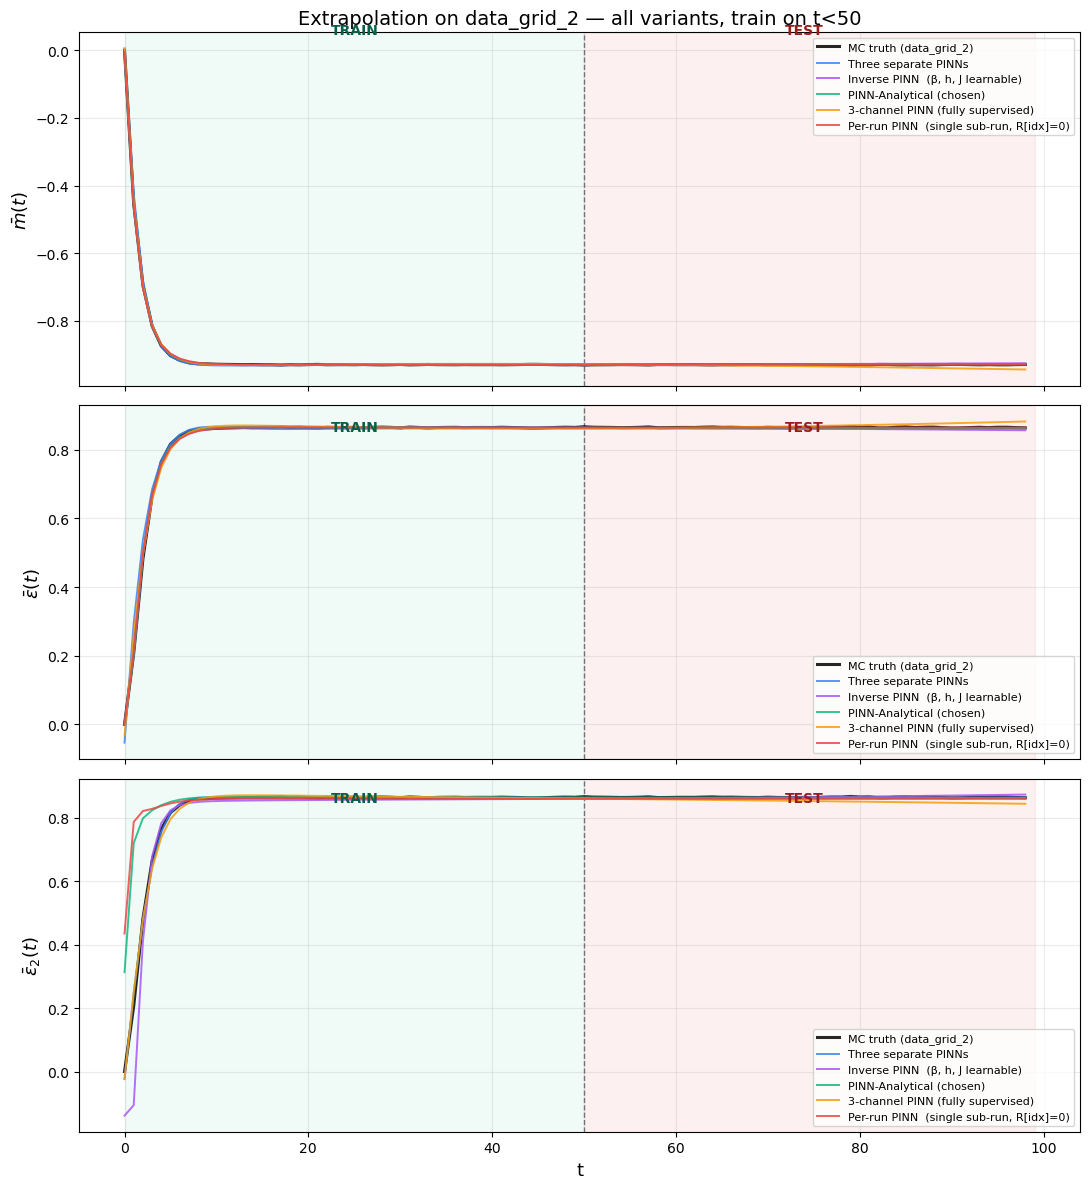

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(11, 12), sharex=True)
for ax, (truth, key_obs, lbl) in zip(axes, [
    (m_bar, 'm_hat', r'$\bar m(t)$'),
    (eps_bar, 'eps_hat', r'$\bar\varepsilon(t)$'),
    (eps2_bar,'eps2_hat', r'$\bar\varepsilon_2(t)$'),
]):
    ax.axvspan(0, T_TRAIN_MAX, alpha=0.06, color='#10b981')
    ax.axvspan(T_TRAIN_MAX, t_grid[-1] + 1.0,   alpha=0.08, color='#ef4444')
    ax.axvline(T_TRAIN_MAX, color='#1e293b', ls='--', lw=1, alpha=0.6)
    ax.plot(t_grid, truth, 'k-', lw=2.2, alpha=0.85, label='MC truth (data_grid_2)')
    for key, r in results_x.items():
        ax.plot(t_grid, r[key_obs], color=colors[key], lw=1.4, alpha=0.85, label=r['name'])
    ax.set_ylabel(lbl)
    ymax = ax.get_ylim()[1]
    ax.text(T_TRAIN_MAX/2, ymax*0.92, 'TRAIN', ha='center', fontsize=10, color='#065f46', fontweight='bold')
    ax.text((T_TRAIN_MAX + t_grid[-1])/2, ymax*0.92, 'TEST',  ha='center', fontsize=10, color='#991b1b', fontweight='bold')
    ax.grid(alpha=0.25); ax.legend(fontsize=8, loc='best')
axes[-1].set_xlabel('t')
axes[0].set_title(f'Extrapolation on data_grid_2 — all variants, train on t<{T_TRAIN_MAX:.0f}')
plt.tight_layout(); plt.show()

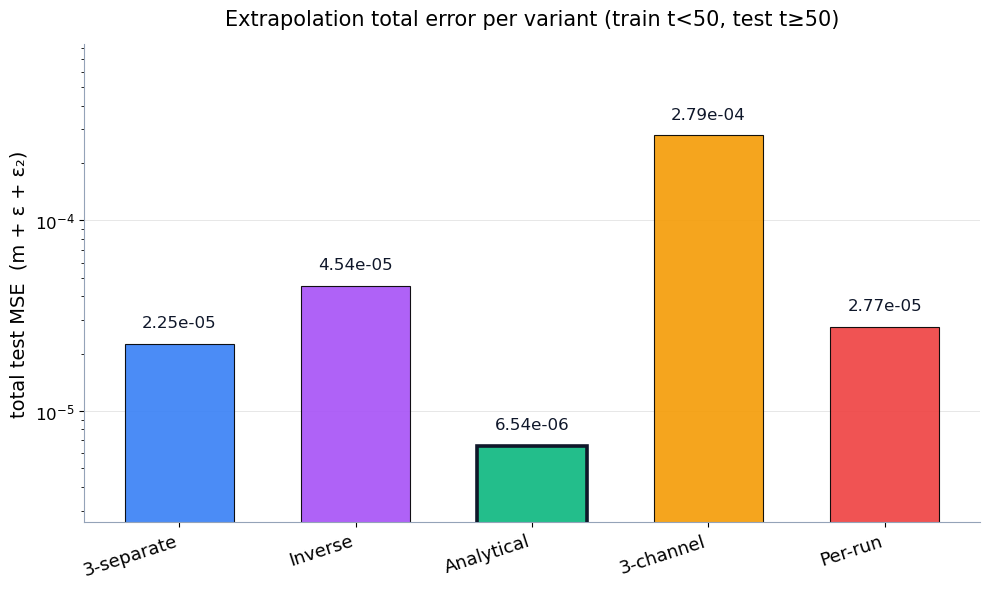

In [12]:
variants_order = ['three_separate', 'inverse', 'analytical', 'three_channel', 'per_run']
short_names = {
    'three_separate': '3-separate',
    'inverse': 'Inverse',
    'analytical': 'Analytical',
    'three_channel': '3-channel',
    'per_run': 'Per-run',
}
bar_colors = {
    'three_separate': '#3b82f6',
    'inverse': '#a855f7',
    'analytical': '#10b981',
    'three_channel': '#f59e0b',
    'per_run': '#ef4444',
}

totals = [
    results_x[k]['mse_m_test'] + results_x[k]['mse_eps_test'] + results_x[k]['mse_eps2_test']
    for k in variants_order
]
names = [short_names[k] for k in variants_order]
cols  = [bar_colors[k]  for k in variants_order]
xs    = np.arange(len(variants_order))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(xs, totals, 0.62, color=cols, edgecolor='black',
              linewidth=0.8, alpha=0.92)

best_i = int(np.argmin(totals))
ax.bar(xs[best_i], totals[best_i], 0.62, color='none',
       edgecolor='#0f172a', linewidth=2.6, zorder=3)

for x, v in zip(xs, totals):
    ax.text(x, v * 1.18, f'{v:.2e}', ha='center', va='bottom',
            fontsize=12, color='#0f172a')

ax.set_xticks(xs)
ax.set_xticklabels(names, rotation=18, ha='right', fontsize=13)
ax.set_yscale('log')
ax.set_ylabel('total test MSE  (m + ε + ε₂)', fontsize=14)
ax.set_title('Extrapolation total error per variant '
             f'(train t<{T_TRAIN_MAX:.0f}, test t≥{T_TRAIN_MAX:.0f})',
             fontsize=15, pad=14)
ax.tick_params(axis='y', labelsize=12)

ymin = min(totals) / 2.5
ymax = max(totals) * 3.0
ax.set_ylim(ymin, ymax)

for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
ax.spines['left'].set_color('#94a3b8')
ax.spines['bottom'].set_color('#94a3b8')
ax.grid(True, axis='y', alpha=0.35, linewidth=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()